<h2>Clustering Analysis - Part 2</h2>
 <ul>
    <li>Hierarchical Clustering</li>
    <li>Gaussian Mixture Models</li>
 </ul>
 

<h2>1. Hierarchical Clustering</h2>

<h3>1.1. Concept </h3><br/>
There are two types of Hierarchical clustering methods: 
    <ul>
    <li>Agglomerative: Bottom up</li>
    <li>Divisive: Top bottom</li>
    </ul>

Agglomerative Hierarchical clustering is a clustering approach seeking to <span style="color:blue">build a hierarchy of clusters</span> using a <span style="color:blue">bottom-up proximity</span> between data points. In a way, HC finds <span style="color:blue">all existing relationships</span> between data points.

<img src="Media/HC_illustration.png"/>

Approach: <b style="color:blue">Find the closest groupings of data points from n clusters to 1 cluster.</b>

<ol>
 <li>Given n data points</li>
 <li>Initialise n clusters</li>
 <li>Merge the closest clusters one at a time</li>
    <li>Until they all merge into a single cluster</li>
    <li>Thus building the dendogram tree (of relationships)</li>
</ol>

<img src="Media/table_clustering.png"/>

<img src="Media/HC_alg.jpg"/>

<h3>1.2. Finding the distance between a cluster and a data point (or cluster) - Linkage Methods</h3>



How does one measure the distance between a 1-data point cluster and a n-data point cluster?

<img src="Media/linkage_methods.png"/>

<h3>1.3. Implementation - HC</h3>

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore') #ignore warnings
#load the dataset
df = pd.read_csv('datasets/OLART_customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


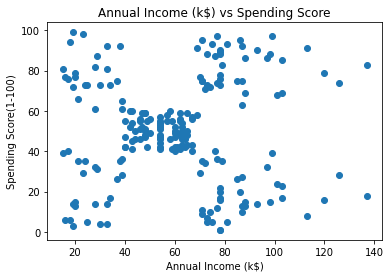

In [33]:
#select data of interest
sub_df = df.iloc[:,[3,4]] #Annual Income against Spending Score
x_1 = sub_df['Annual Income (k$)']
x_2 = sub_df['Spending Score (1-100)']

#plotting the data of interest
plt.figure()
plt.scatter(x_1,x_2)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score(1-100)')
plt.title('Annual Income (k$) vs Spending Score')
plt.show()

In [34]:
#Dendogram formation
from scipy.cluster.hierarchy import ward, dendrogram
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

linkage_matrix = sch.linkage(sub_df, method='average', metric='euclidean')


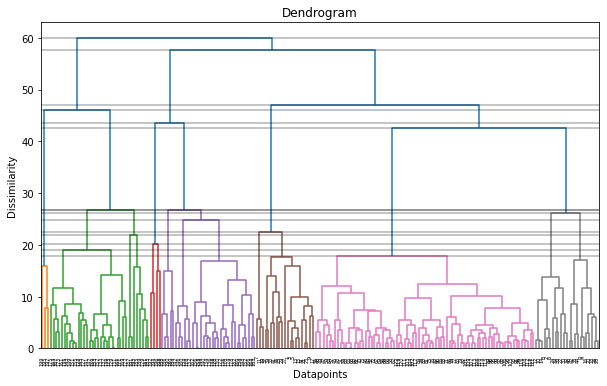

In [35]:
plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(linkage_matrix)
z = linkage_matrix[:,2]
for i in range(1,16):
    rng = [z[-i],z[-i]]
    dom = [0,40000]
    plt.plot(dom,rng,'black', alpha=0.3)

plt.title('Dendrogram')
plt.xlabel('Datapoints')
plt.ylabel('Dissimilarity')
plt.show()

<h3>1.4 Find the Optimal K from the dendogram tree</h3>

Natural clusters: <b style="color:blue">"Look for points in the dendogram where the distances between clusters suddenly increases"</b>

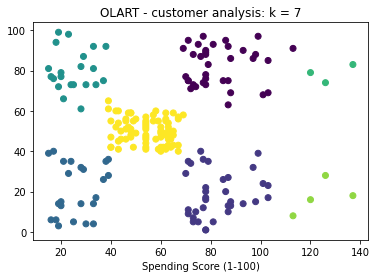

In [36]:
from sklearn.cluster import AgglomerativeClustering

k_choice = 7
hc = AgglomerativeClustering(n_clusters=k_choice, linkage='average').fit(sub_df)
clusterIds = hc.labels_
plt.figure()
plt.xlabel(sub_df.columns[0])
plt.xlabel(sub_df.columns[1])
plt.scatter(x_1,x_2,c=clusterIds)
plt.title('OLART - customer analysis: k = %d'%k_choice)
plt.show()

<h3>1.4. K-Means vs Hierarchical Clustering</h3>

<table>
    <tr>
        <td>K-Means</td><td>HC</td>
    </tr>
    <tr>
        <td>Works well for spherical cluster groups</td><td>Reproducible results - same tree all the time</td>
    </tr>
    <tr>
        <td>Computationally efficient (good for large datasets)</td><td>More adaptable to any cluster shape</td>
    </tr>
    <tr>
        <td>Require apriori knowledge of k-clusters</td><td>Computationally expensive for large datasets</td>
    </tr>
    <tr>
        <td></td><td>More informative and interpretable</td>
    </tr>
</table>


<p style="color:blue">Which to Choose? - Guidelines</p>
<ul>
    <li>If there is a specific number of clusters in the data, but the group they belong is unknown,  <b>K-Means</b>
    </li>
    <li>If the number of cluster group is unknown and the dataset is not so large, <b>Hierarchical clustering</b>
    </li>
    <li>If the dataset is too large, <b>K-Means</b></li>
    <li>If there is a need for in depth interpretation of data grouping, <b>Hierarchical clustering</b></li>
</ul>

This cost function is solved using <span style="color:blue">numerical optimisation theory (gradient-methods) or the Expectation-Maximisation algorithm</span>.

<table>
  <tr>
    <th>Criteria</th>
    <th>K-Means</th>
    <th>Gaussian Mixture Models (GMMs)</th>
    <th>Hierarchical Clustering (HC)</th>
  </tr>
  <tr>
    <td>Data Distribution</td>
    <td>Well-separated, spherical clusters</td>
    <td>Complex or overlapping clusters</td>
    <td>No specific assumptions, adapts to different data distributions</td>
  </tr>
  <tr>
    <td>Cluster Shape</td>
    <td>Spherical clusters</td>
    <td>Spherical and ellipsoidal clusters</td>
    <td>No restrictions on cluster shape</td>
  </tr>
  <tr>
    <td>Cluster Assignment</td>
    <td>Hard assignment (each point belongs to only one cluster)</td>
    <td>Soft assignment (points can belong to multiple clusters with probabilities)</td>
    <td>Can perform both hard and soft clustering</td>
  </tr>
  <tr>
    <td>Number of Clusters</td>
    <td>Need to specify the number of clusters (K)</td>
    <td>Need to specify the number of clusters (K)</td>
    <td>Can determine the number of clusters using dendrogram or other methods</td>
  </tr>
  <tr>
    <td>Computational Efficiency</td>
    <td>Fast and scalable, suitable for large datasets</td>
    <td>Can be slower than K-Means, especially for large datasets</td>
    <td>Can be computationally intensive, especially for large datasets or single-linkage</td>
  </tr>
</table>